In [1]:
import uproot
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
file = uproot.open("build/yz.root")

print(file.keys()) 
tree = file["yz"]
df = tree.arrays(library="pd")

['yz;1']


### STEP 1
Plottare tutte e quantità del file

In [3]:
custom_ranges = {
    'radius': None,
    'nbHits': None,
    'nbScoredHits': None,
    'y': None,
    'z': None,
    'Einc': (-0.02, 0.02)
}

cols_to_plot = ['radius', 'nbHits', 'nbScoredHits', 'y', 'z', 'Einc']

units = {
    'radius': ' [nm]',
    'nbHits': '',
    'nbScoredHits': '',
    'y': ' [keV/um]',
    'z': ' [Gy]',
    'Einc': ' [MeV]'
} # Controlla se sto facendo bene...!

count = len(df)
# Senza [1:], includi TUTTI gli indici trovati
counts = df['nbScoredHits'].value_counts().sort_index()

n_zeros = (df['nbScoredHits'] == 0).sum()
print(f"Number of events with nbEdep = 0: {n_zeros}")

for i, count in counts.items():
    print(f"Number of events with nbEdep = {int(i)}: {int(count)}")

# Somma totale di tutto quello che hai trovato
print(f"Total of number of Event = {counts.sum()}")

Number of events with nbEdep = 0: 0
Number of events with nbEdep = 1: 1594
Number of events with nbEdep = 2: 1109
Number of events with nbEdep = 3: 1202
Number of events with nbEdep = 4: 1318
Number of events with nbEdep = 5: 1215
Number of events with nbEdep = 6: 1203
Number of events with nbEdep = 7: 1121
Number of events with nbEdep = 8: 1088
Number of events with nbEdep = 9: 1040
Number of events with nbEdep = 10: 1044
Number of events with nbEdep = 11: 1192
Number of events with nbEdep = 12: 962
Number of events with nbEdep = 13: 804
Number of events with nbEdep = 14: 687
Number of events with nbEdep = 15: 676
Number of events with nbEdep = 16: 664
Number of events with nbEdep = 17: 580
Number of events with nbEdep = 18: 530
Number of events with nbEdep = 19: 451
Number of events with nbEdep = 20: 430
Number of events with nbEdep = 21: 375
Number of events with nbEdep = 22: 366
Number of events with nbEdep = 23: 325
Number of events with nbEdep = 24: 305
Number of events with nbEd

 Istogramma radius ha un range impostato a: None
 Istogramma nbHits ha un range impostato a: None
 Istogramma nbScoredHits ha un range impostato a: None
 Istogramma y ha un range impostato a: None
 Istogramma z ha un range impostato a: None
 Istogramma Einc ha un range impostato a: (-0.02, 0.02)


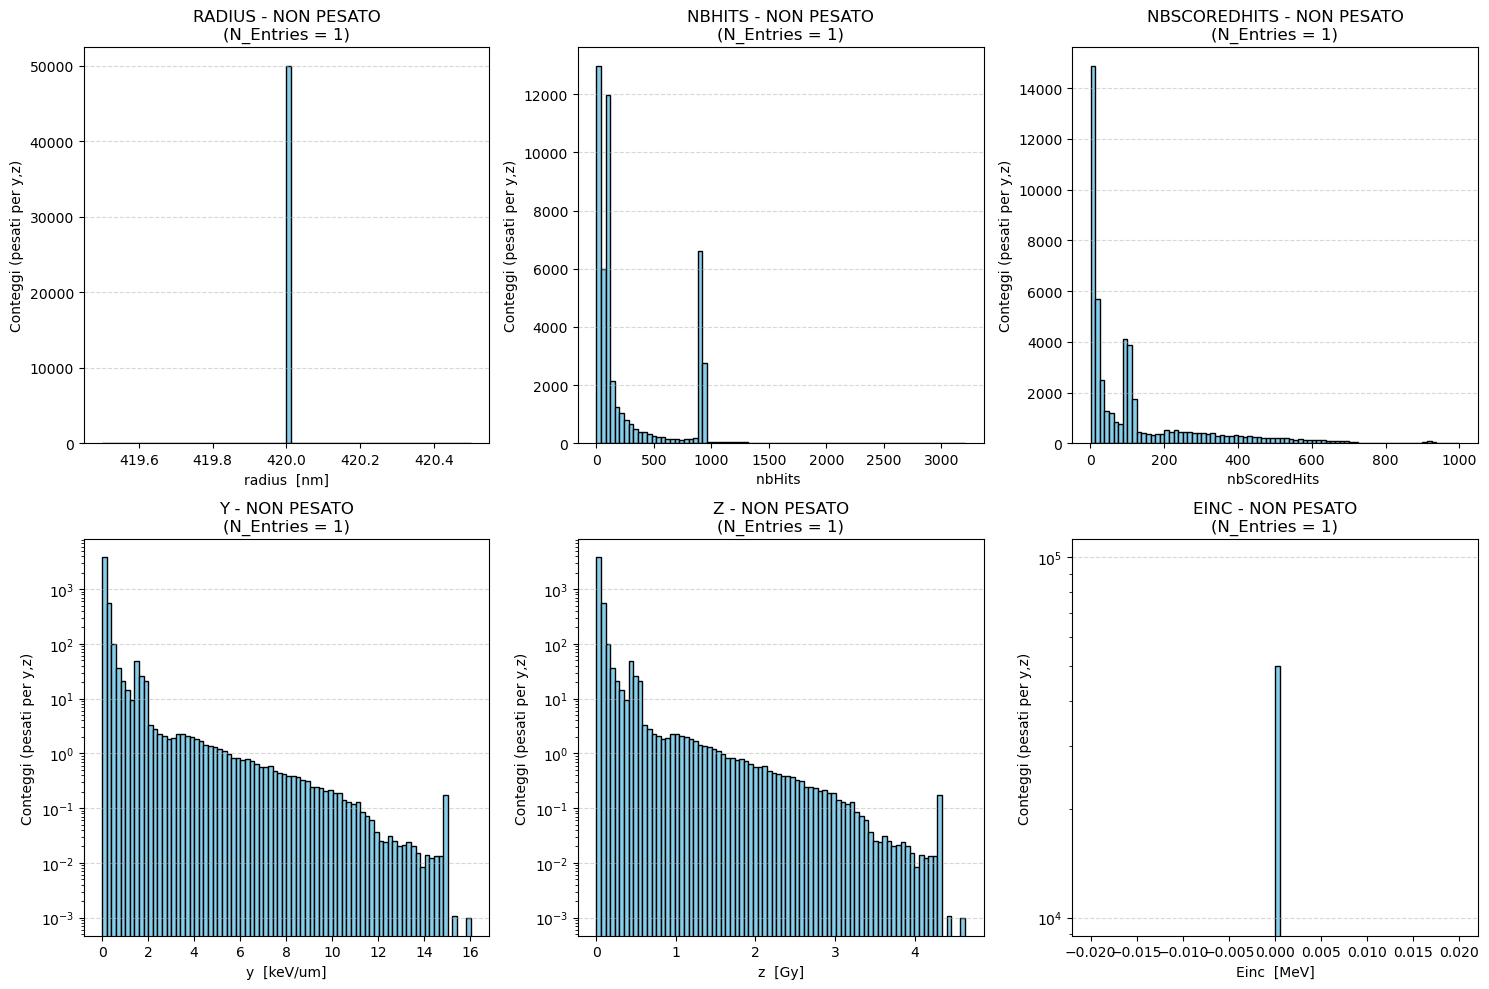

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# 1. CALCOLO PESI (Una sola volta)
# Se nbScoredHits è > 0, il peso è 1/nbScoredHits, altrimenti è 0
df['weight'] = 1.0 / df['nbScoredHits']

# 2. DEFINIZIONE DELLE COLONNE E RANGE (Puoi personalizzare i range qui)
cols_to_plot = ['radius', 'nbHits', 'nbScoredHits', 'y', 'z', 'Einc']

# 3. PLOTTING
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    current_range = custom_ranges.get(col)
    print(f" Istogramma {col} ha un range impostato a: {current_range}")
    # Applichiamo il peso SOLO se la colonna è 'y' o 'z'
    current_weights = df['weight'] if col in ['y', 'z'] else None
    
    # Decidiamo la scala logaritmica (opzionale, basato sui tuoi dati)
    is_log = col in ['y', 'z', 'Einc']
    
    # Plot dell'istogramma
    axes[i].hist(df[col], bins=80, range=custom_ranges.get(col), 
                 color='skyblue', edgecolor='black', log=is_log, 
                 weights=current_weights)
    
    axes[i].set_title(f'{col.upper()} - NON PESATO\n(N_Entries = {count})')
    axes[i].set_xlabel(f'{col} {units.get(col, "")}')
    axes[i].set_ylabel('Conteggi (pesati per y,z)')
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

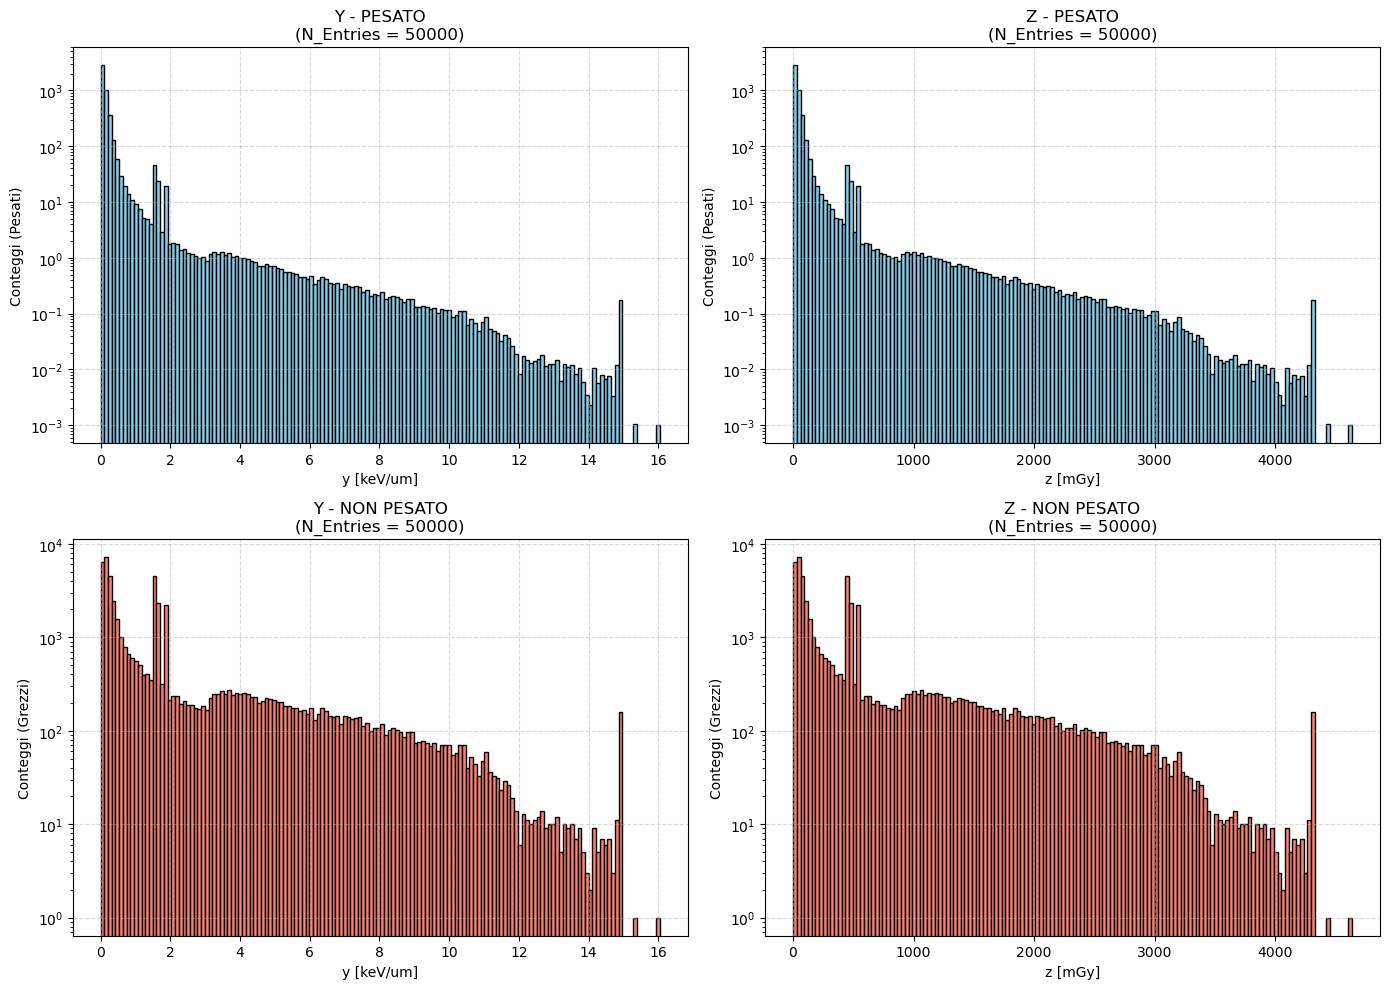

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Fattori di conversione
scales = {'y': 1.0, 'z': 1000.0}
units_label = {'y': 'keV/um', 'z': 'mGy'}

# Creiamo la figura
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))

# Definiamo le colonne
cols = ['y', 'z']

for i, col in enumerate(cols):
    data = df[col] * scales[col]
    
    # Calcolo conteggi
    # Per il non pesato: numero puro di eventi
    count = len(df)
    
    # 1. GRAFICO PESATO (Corretto)
    axes[0, i].hist(data, bins=150, range=None, weights=df['weight'], 
                    color='skyblue', edgecolor='black', log=True)
    axes[0, i].set_title(f'{col.upper()} - PESATO\n(N_Entries = {count:.0f})')
    axes[0, i].set_ylabel('Conteggi (Pesati)')
    axes[0, i].set_xlabel(f'{col} [{units_label[col]}]')
    axes[0, i].grid(linestyle='--', alpha=0.5)

    # 2. GRAFICO NON PESATO (Grezzo)
    axes[1, i].hist(data, bins=150, range=None, weights=None, 
                    color='salmon', edgecolor='black', log=True)
    axes[1, i].set_title(f'{col.upper()} - NON PESATO\n(N_Entries = {count})')
    axes[1, i].set_ylabel('Conteggi (Grezzi)')
    axes[1, i].set_xlabel(f'{col} [{units_label[col]}]')
    axes[1, i].grid(linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Step 2
Entriamo nello specifico della lineal energy, y, e della specific energy, z.

Calcoliamo $y_F$ e $z_F$.

In [6]:
# Filtriamo i dati per evitare divisioni per zero o valori non fisici
y_data = df[df['y'] > 0]['y']
z_data = df[df['z'] > 0]['z']

### Step 3
Intera pipeline dalle quantità microdosimetriche a MKM e LQ model.

In [7]:
R_d = 0.420       # Raggio del dominio sensibile in micrometri (420 nm -> 0.420 um)
R_n = 4.0         # Raggio del nucleo cellulare in micrometri (4.0 um)
y0 = 150.0        # Parametro di saturazione MKM [keV/um]
alpha_0 = 0.147   # Radiosensibilità lineare di riferimento [Gy^-1]
beta_cell = 0.02  # Coefficiente quadratico [Gy^-2]

# Costante di conversione microdosimetrica sferica: passo da keV/um a Gy
k_conv = 0.12015 / (R_d*R_d)
rapporto_volumi = (R_d / R_n)**3 

In [8]:
# Calcolo analitico di y_F (Mean) e y_D (Dose-mean) per la diagnostica
y_f = y_data.mean()
y_d_dose_mean = (y_data**2).sum() / y_data.sum()

# Calcolo di y* (energia lineare media pesata in dose satura per il MKM)
y_numerator = np.sum((y0**2) * (1 - np.exp(-(y_data**2) / (y0**2))))
y_denominator = np.sum(y_data)
y_star = y_numerator / y_denominator

# Calcolo dell'Alpha cellulare effettivo secondo il modello MKM
alpha_cell = alpha_0 + (beta_cell * k_conv * y_star)

print("\n--- DIAGNOSTICA PARAMETRI FISICI ---")
print(f"y_F (Frequency-mean): {y_f:.4f} keV/um")
print(f"y_D (Dose-mean):      {y_d_dose_mean:.4f} keV/um")
print(f"y* (Satura MKM):      {y_star:.4f} keV/um")
print(f"Alpha Cell (MKM):     {alpha_cell:.4f} Gy^-1")
print(f"Dose media per singolo hit (z_F): {z_data.mean():.4f} Gy")
print("------------------------------------\n")


--- DIAGNOSTICA PARAMETRI FISICI ---
y_F (Frequency-mean): 2.0367 keV/um
y_D (Dose-mean):      5.7073 keV/um
y* (Satura MKM):      5.6975 keV/um
Alpha Cell (MKM):     0.2246 Gy^-1
Dose media per singolo hit (z_F): 0.5888 Gy
------------------------------------



In [ ]:
casi_decadimenti = np.linspace(0, 20000, 100) 

# Liste per salvare le MEDIE di ogni punto N
risultati_sopravvivenza = []
dosi_medie_nucleo = []
rbe_lista = []

# Liste per salvare le DEVIAZIONI STANDARD di ogni punto N
std_sopravvivenza = []
std_rbe = []

# Numero di simulazioni ripetute per ogni punto N
n_sim = 300
print("Numero di isotopi decaduti:\n")
for N in casi_decadimenti:
    print(casi_decadimenti, "\n")
    S_temp = []
    D_temp = []
    rbe_temp = []
    
    for _ in range(n_sim):
        z_sample = z_data.sample(int(N), replace=True)
        z_sample_sum = z_sample.sum()
            
        D_nucleo = z_sample_sum * rapporto_volumi
        
        # Sopravvivenza cellulare
        S = np.exp(-alpha_cell * D_nucleo - beta_cell * (D_nucleo**2))
        
        if D_nucleo > 0:
            rbe = (np.sqrt(alpha_0**2 + 4 * beta_cell * (alpha_cell * D_nucleo + beta_cell * (D_nucleo**2))) - alpha_0) / (2 * beta_cell * D_nucleo)
        else:
            rbe = alpha_cell / alpha_0
            
        S_temp.append(S)
        D_temp.append(D_nucleo)
        rbe_temp.append(rbe)
    
    # Salvataggio medie e deviazioni standard
    risultati_sopravvivenza.append(np.mean(S_temp))
    dosi_medie_nucleo.append(np.mean(D_temp))
    rbe_lista.append(np.mean(rbe_temp))
    
    std_sopravvivenza.append(np.std(S_temp))
    std_rbe.append(np.std(rbe_temp))

log_S_rev = np.log(np.array(risultati_sopravvivenza)[::-1])
casi_rev = casi_decadimenti[::-1]
decadimenti_soglia = np.interp(np.log(0.10), log_S_rev, casi_rev)

dosi_nucleo_array = np.array(dosi_medie_nucleo)
dose_soglia_sim = np.interp(np.log(0.10), log_S_rev, dosi_nucleo_array[::-1])
dose_soglia_ref = (-alpha_0 + np.sqrt(alpha_0**2 - 4 * beta_cell * np.log(0.10))) / (2 * beta_cell)
rbe_al_10 = dose_soglia_ref / dose_soglia_sim

rbe_medi_analitici = np.array(rbe_lista)
rbe_soglia_grafico = np.interp(decadimenti_soglia, casi_decadimenti, rbe_medi_analitici)

# Conversione in array Numpy per le operazioni grafiche
y_S = np.array(risultati_sopravvivenza)
err_S = np.array(std_sopravvivenza)
y_RBE = np.array(rbe_medi_analitici)
err_RBE = np.array(std_rbe)



Numero di isotopi decaduti:

[    0.           202.02020202   404.04040404   606.06060606
   808.08080808  1010.1010101   1212.12121212  1414.14141414
  1616.16161616  1818.18181818  2020.2020202   2222.22222222
  2424.24242424  2626.26262626  2828.28282828  3030.3030303
  3232.32323232  3434.34343434  3636.36363636  3838.38383838
  4040.4040404   4242.42424242  4444.44444444  4646.46464646
  4848.48484848  5050.50505051  5252.52525253  5454.54545455
  5656.56565657  5858.58585859  6060.60606061  6262.62626263
  6464.64646465  6666.66666667  6868.68686869  7070.70707071
  7272.72727273  7474.74747475  7676.76767677  7878.78787879
  8080.80808081  8282.82828283  8484.84848485  8686.86868687
  8888.88888889  9090.90909091  9292.92929293  9494.94949495
  9696.96969697  9898.98989899 10101.01010101 10303.03030303
 10505.05050505 10707.07070707 10909.09090909 11111.11111111
 11313.13131313 11515.15151515 11717.17171717 11919.19191919
 12121.21212121 12323.23232323 12525.25252525 12727.27272

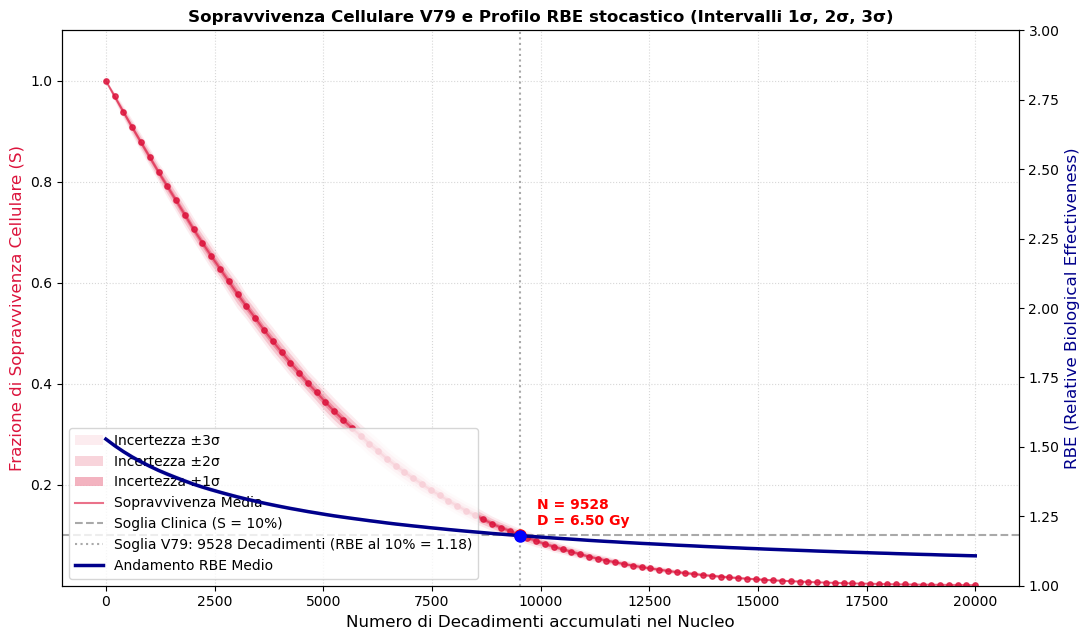

In [10]:
# --- GRAFICI MULTI-SIGMA CON FASCE STRATIFICATE ---
fig, ax1 = plt.subplots(figsize=(11, 6.5))

# ASSE SINISTRO: Frazione di Sopravvivenza (S)
color_s = 'crimson'

# Stratificazione bande Sopravvivenza (tagliate a 1e-6 per asse logaritmico)
ax1.fill_between(casi_decadimenti, np.maximum(1e-6, y_S - 3*err_S), y_S + 3*err_S, color=color_s, alpha=0.08, edgecolor='none', label='Incertezza ±3σ')
ax1.fill_between(casi_decadimenti, np.maximum(1e-6, y_S - 2*err_S), y_S + 2*err_S, color=color_s, alpha=0.18, edgecolor='none', label='Incertezza ±2σ')
ax1.fill_between(casi_decadimenti, np.maximum(1e-6, y_S - 1*err_S), y_S + 1*err_S, color=color_s, alpha=0.32, edgecolor='none', label='Incertezza ±1σ')

ax1.scatter(casi_decadimenti, y_S, color=color_s, s=15, alpha=0.8, zorder=3)
ax1.plot(casi_decadimenti, y_S, color=color_s, linestyle='-', alpha=0.6, linewidth=1.5, zorder=3, label='Sopravvivenza Media')

ax1.set_yscale('linear')
ax1.set_ylim(1e-5, 1.1)  
ax1.set_xlabel("Numero di Decadimenti accumulati nel Nucleo", fontsize=12)
ax1.set_ylabel("Frazione di Sopravvivenza Cellulare (S)", color=color_s, fontsize=12)
ax1.grid(True, which="both", linestyle=":", alpha=0.5)

# ASSE DESTRO: Profilo dell'RBE
ax2 = ax1.twinx()
color_rbe = 'darkblue'

# Stratificazione bande RBE
ax2.fill_between(casi_decadimenti, y_RBE - 3*err_RBE, y_RBE + 3*err_RBE, color=color_rbe, alpha=0.06, edgecolor='none')
ax2.fill_between(casi_decadimenti, y_RBE - 2*err_RBE, y_RBE + 2*err_RBE, color=color_rbe, alpha=0.15, edgecolor='none')
ax2.fill_between(casi_decadimenti, y_RBE - 1*err_RBE, y_RBE + 1*err_RBE, color=color_rbe, alpha=0.28, edgecolor='none')

ax2.plot(casi_decadimenti, y_RBE, color=color_rbe, linestyle='-', linewidth=2.5, label='Andamento RBE Medio', zorder=4)
ax2.set_ylabel("RBE (Relative Biological Effectiveness)", color=color_rbe, fontsize=12)
ax2.set_ylim(1.0, 3.0) 

# --- LINEE DI SOGLIA ---
line_soglia = ax1.axhline(y=0.10, color='darkgray', linestyle='--', linewidth=1.5, label='Soglia Clinica (S = 10%)')
line_vert = ax1.axvline(x=decadimenti_soglia, color='darkgray', linestyle=':', linewidth=1.5,
                        label=f'Soglia V79: {int(np.ceil(decadimenti_soglia))} Decadimenti (RBE al 10% = {rbe_al_10:.2f})')

# Marker di intersezione grafica
ax1.plot(decadimenti_soglia, 0.10, marker='o', color='red', markersize=8, zorder=5)
ax2.plot(decadimenti_soglia, rbe_soglia_grafico, marker='o', color='blue', markersize=8, zorder=5)

# Box di testo informativo vicino all'incrocio
ax1.text(decadimenti_soglia + 400, 0.12, f"N = {int(np.ceil(decadimenti_soglia))}\nD = {dose_soglia_sim:.2f} Gy", 
         fontsize=10, color='red', fontweight='bold', bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))

# Unione delle legende (evitando duplicati per l'RBE che condivide le stesse bande)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=10, loc='lower left')

plt.title("Sopravvivenza Cellulare V79 e Profilo RBE stocastico (Intervalli 1σ, 2σ, 3σ)", fontsize=12, fontweight='bold')
fig.tight_layout()
plt.show()

Qui vado solo a "migliorare" la visibilità del plot.

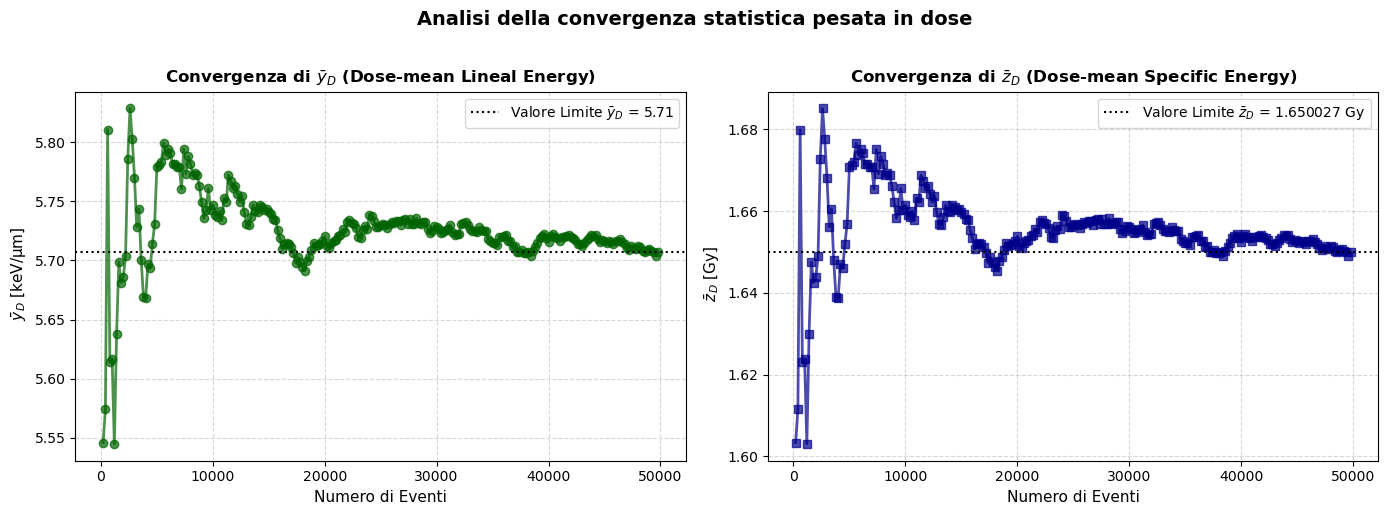

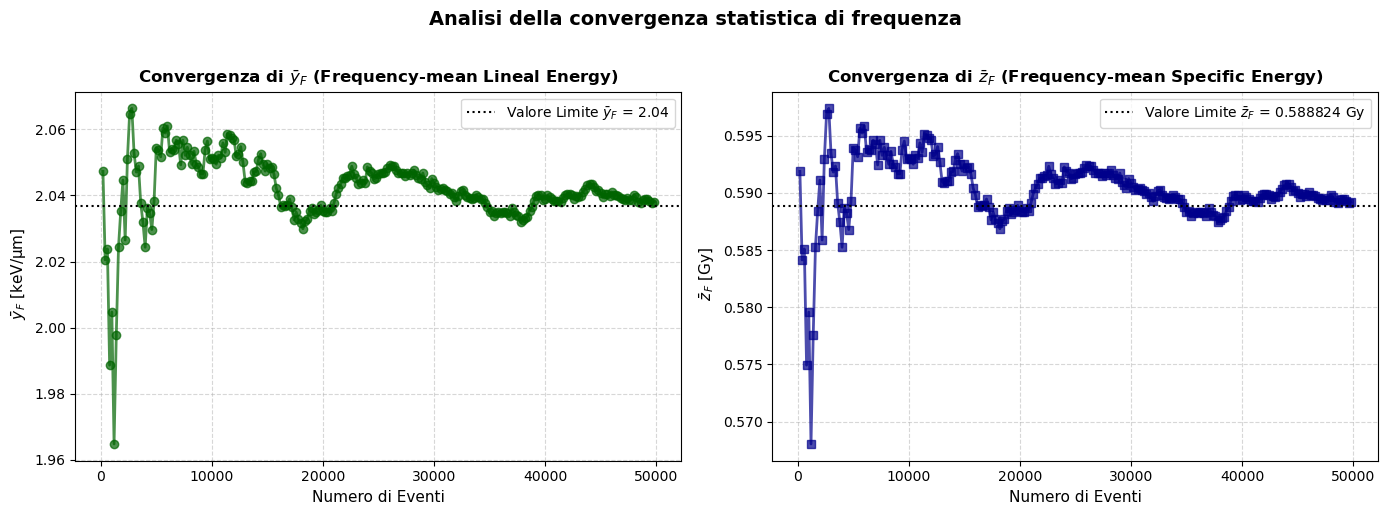

In [11]:
# ==============================================================================
# STUDIO DELLA CONVERGENZA STATISTICA DI y_D E z_D (PESATI IN DOSE)
# ==============================================================================
# Partiamo da un numero minimo di eventi (es. 'step') per evitare divisioni per zero all'inizio
step = 200
step_statistica = np.arange(step, len(y_data), step) 

y_f_cumulativi = []
z_f_cumulativi = []

y_d_cumulativi = []
z_d_cumulativi = []

# Calcoliamo i valori "di riferimento" (limiti) sull'intero dataset per le linee orizzontali
#y_f e z_f
ref_y_f = np.mean(y_data)
ref_z_f = np.mean(z_data)
#y_d e z_d
ref_y_d = np.sum(y_data**2) / np.sum(y_data)
ref_z_d = np.sum(z_data**2) / np.sum(z_data)

for n_eventi in step_statistica:
    # Estraiamo i sottogruppi
    y_sub = y_data[:n_eventi]
    z_sub = z_data[:n_eventi]
    
    # Calcolo della media pesata in dose (Dose-mean)
    # Formula: sum(x^2) / sum(x)
    y_f_cumulativi.append(np.mean(y_sub))
    z_f_cumulativi.append(np.mean(z_sub))
    y_d_cumulativi.append(np.sum(y_sub**2) / np.sum(y_sub))
    z_d_cumulativi.append(np.sum(z_sub**2) / np.sum(z_sub))

# Convertiamo in array
y_f_cumulativi = np.array(y_f_cumulativi)
z_f_cumulativi = np.array(z_f_cumulativi)

y_d_cumulativi = np.array(y_d_cumulativi)
z_d_cumulativi = np.array(z_d_cumulativi)

# --- GENERAZIONE DEL GRAFICO DI CONVERGENZA PESATA ---
fig, (ax_y, ax_z) = plt.subplots(1, 2, figsize=(14, 5))

# 1. Plot per y_D
ax_y.plot(step_statistica, y_d_cumulativi, marker='o', color='darkgreen', linewidth=2, linestyle='-', alpha=0.7)
ax_y.axhline(y=ref_y_d, color='black', linestyle=':', label=f'Valore Limite $\\bar{{y}}_D$ = {ref_y_d:.2f}')
ax_y.set_xlabel("Numero di Eventi", fontsize=11)
ax_y.set_ylabel(r" $\bar{y}_D$ [keV/µm]", fontsize=11)
ax_y.set_title(r"Convergenza di $\bar{y}_D$ (Dose-mean Lineal Energy)", fontsize=12, fontweight='bold')
ax_y.grid(True, linestyle='--', alpha=0.5)
ax_y.legend()

# 2. Plot per z_D
ax_z.plot(step_statistica, z_d_cumulativi, marker='s', color='darkblue', linewidth=2, linestyle='-', alpha=0.7)
ax_z.axhline(y=ref_z_d, color='black', linestyle=':', label=f'Valore Limite $\\bar{{z}}_D$ = {ref_z_d:.6f} Gy')
ax_z.set_xlabel("Numero di Eventi", fontsize=11)
ax_z.set_ylabel(r" $\bar{z}_D$ [Gy]", fontsize=11)
ax_z.set_title(r"Convergenza di $\bar{z}_D$ (Dose-mean Specific Energy)", fontsize=12, fontweight='bold')
ax_z.grid(True, linestyle='--', alpha=0.5)
ax_z.legend()

plt.suptitle("Analisi della convergenza statistica pesata in dose", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# --- GENERAZIONE DEL GRAFICO DI CONVERGENZA NON PESATA ---
fig, (ax_y, ax_z) = plt.subplots(1, 2, figsize=(14, 5))

# 1. Plot per y_F
ax_y.plot(step_statistica, y_f_cumulativi, marker='o', color='darkgreen', linewidth=2, linestyle='-', alpha=0.7)
ax_y.axhline(y=ref_y_f, color='black', linestyle=':', label=f'Valore Limite $\\bar{{y}}_F$ = {ref_y_f:.2f}')
ax_y.set_xlabel("Numero di Eventi", fontsize=11)
ax_y.set_ylabel(r" $\bar{y}_F$ [keV/µm]", fontsize=11)
ax_y.set_title(r"Convergenza di $\bar{y}_F$ (Frequency-mean Lineal Energy)", fontsize=12, fontweight='bold')
ax_y.grid(True, linestyle='--', alpha=0.5)
ax_y.legend()

# 2. Plot per z_F
ax_z.plot(step_statistica, z_f_cumulativi, marker='s', color='darkblue', linewidth=2, linestyle='-', alpha=0.7)
ax_z.axhline(y=ref_z_f, color='black', linestyle=':', label=f'Valore Limite $\\bar{{z}}_F$ = {ref_z_f:.6f} Gy')
ax_z.set_xlabel("Numero di Eventi", fontsize=11)
ax_z.set_ylabel(r" $\bar{z}_F$ [Gy]", fontsize=11)
ax_z.set_title(r"Convergenza di $\bar{z}_F$ (Frequency-mean Specific Energy)", fontsize=12, fontweight='bold')
ax_z.grid(True, linestyle='--', alpha=0.5)
ax_z.legend()

plt.suptitle("Analisi della convergenza statistica di frequenza", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
